# Predict the pedestal using ESCAPE for ITER baseline scenario

In [1]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys
from pathlib import Path
import urllib.request # needed for geqdsk import
ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(ROOT))
from src.profiles_loop_solve import profiles_loop_solve

from examples.device_prediction.helper_functions import calc_pressure_profile

Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified


In [2]:
mhd_fp = '/mnt/homes_global/jal2351/software/saarelma-conner-ped/examples/device_prediction/ITER/ITER_Hmode_tMakerEx.geqdsk'

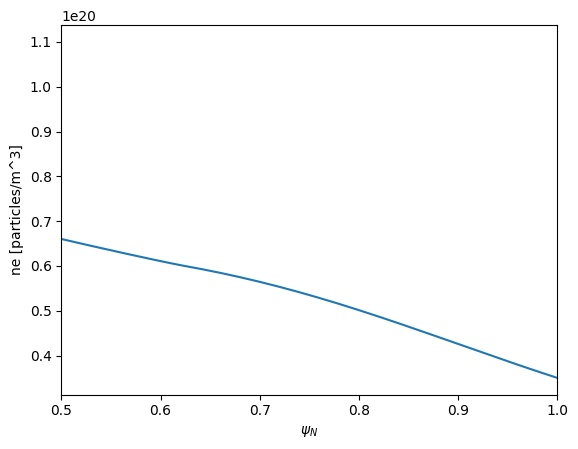

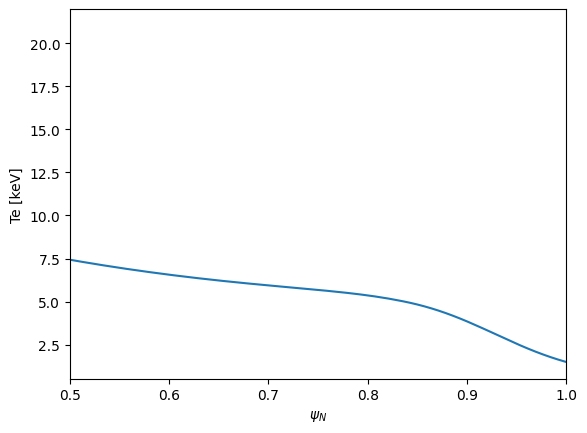

In [3]:
profiles = np.load('ITER_Hmode_tMakerEx_profiles.npy',allow_pickle=True).item()

psi_n = profiles['psi_n']
ne_ref = profiles['ne']
Te_ref = profiles['Te'] / 1e3 # keV

fig,ax = plt.subplots()
ax.plot(psi_n**2, ne_ref, label='ne')
ax.set_xlabel(r'$\psi_N$')
ax.set_ylabel('ne [particles/m^3]')

fig1,ax1 = plt.subplots()
ax1.plot(psi_n**2, Te_ref, label='Te')
ax1.set_xlabel(r'$\psi_N$')
ax1.set_ylabel('Te [keV]')

ax.set_xlim(0.5, 1)
ax1.set_xlim(0.5, 1)

manual_profs = {
    'ne': ne_ref,
    'Te': Te_ref,
    'psi_N_ne': psi_n,
    'psi_N_Te': psi_n
}


In [4]:
# Parameters for ESCAPE #

# Output directory
out_dir = 'ITER_output_logs'
Path(out_dir).mkdir(parents=True, exist_ok=True)

verbose = True
verbose_sc = True

# Scan parameters
x_res = 50
free_params = {
    'alpha_crit': 10,
    'C_KBM': 0.1,
    'De_chie_etg': 1,
    'nFC_x0': 1e15,
    'ncx_x0_ratio': 17.8
}
epednn_model = 'EPED1' # 'EPED1' or 'EPED_SPARC'
eped_tol_max = 1e-5
eped_iter_max = 5
EPEDNN_core = 'previous T, stiched ne'
kbm_treatment = "picard"
kbm_gate_eps = 0.1
picard_gate_mode = "average"
picard_max_it = 50
picard_rtol = 1e-8
picard_relax = 1.0

verbose_EPEDNNloop = True
verbose_sc = False

Setting up EPEDNN...
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Base model built.
------------------------------------------------
ESCAPE Loop Iter 0
betan: [2.03517747]
Pedestal height: 0.06295365915155775 MPa, Pedestal width: 0.032784825818991406 (psi_N)
Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 1
betan: [3.07570754]
Pedestal height: 0.06839009751505233 MPa, Pedestal width: 0.03408193253409373 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.12592043331746874
Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 2
betan: [3.21116315]
Pedestal height: 0.06829579531443114 MPa, Pedestal width: 0.034109063949795855 (psi_N)
Normalized pedestal pressure height and width tolerance: -0.0005828222952059605
Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 3
betan: [3.25255999]
Pedestal height

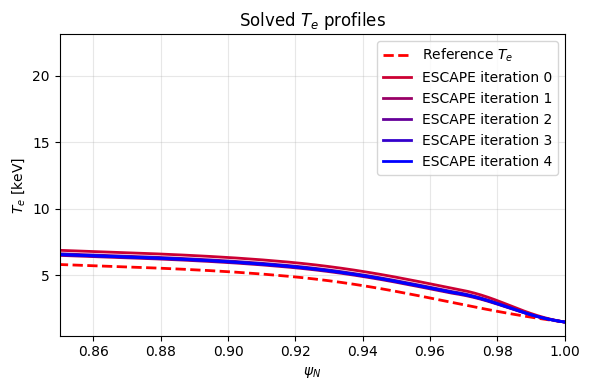

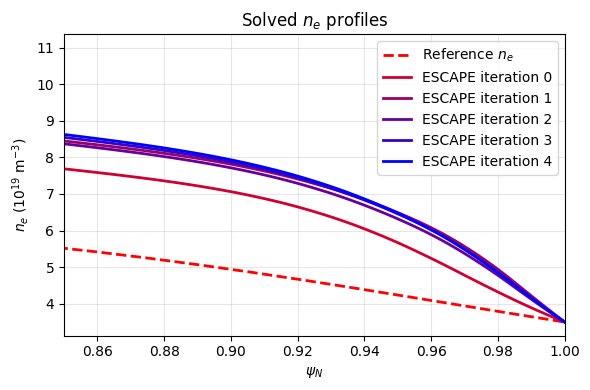

In [5]:
# Model run
ped_wid, ped_h_out = profiles_loop_solve(
    MHD_FP = mhd_fp,
    kprof_loc = 'manual profs',
    manual_profs = manual_profs,
    P_tot_e = 40e6, # from https://iopscience-iop-org.ezproxy.cul.columbia.edu/article/10.1088/0029-5515/49/6/065012/pdf
    psi_N_inner = 0.85,
    out_dir = out_dir,
    species = 'D-T',
    # Z_i = Zeff,
    x_res = x_res,
    free_params = free_params,
    eped_tol_max = eped_tol_max,
    eped_iter_max = eped_iter_max,
    kbm_gate_eps = kbm_gate_eps,
    kbm_treatment = kbm_treatment,
    picard_gate_mode = picard_gate_mode,
    picard_max_it = picard_max_it,
    picard_rtol = picard_rtol,
    picard_relax = picard_relax,
    ig = 'manual',
    epednn_model = epednn_model,
    verbose = verbose_EPEDNNloop,
    verbose_sc = verbose_sc,
)

In [6]:
# Profile pressure at the EPEDNN-predicted pedestal top (psi_N = 1 - ped_wid)
psi_N_p, p_Pa, p_mode = calc_pressure_profile(manual_profs)
psi_ped_top = 1.0 - float(ped_wid)
p_at_ped_top = float(np.interp(psi_ped_top, psi_N_p, p_Pa))

print(f'Pressure formula: {p_mode}')
print(f'EPEDNN ped_top at psi_N = 1 - ped_wid = {psi_ped_top:.6f}')
print(f'Profile p(psi_ped_top) = {p_at_ped_top/1e3:.3f} kPa  ({p_at_ped_top/1e6:.4f} MPa)')
print(f'EPEDNN ped_h_out       = {float(ped_h_out)*1e3:.3f} kPa  ({float(ped_h_out):.4f} MPa)')
print(f'Accuracy of EPEDNN pedestal heightprediction: {100*(float(p_at_ped_top/1e6) - float(ped_h_out))/float(ped_h_out):.2f}%')


Pressure formula: 2*ne*Te
EPEDNN ped_top at psi_N = 1 - ped_wid = 0.965743
Profile p(psi_ped_top) = 38.628 kPa  (0.0386 MPa)
EPEDNN ped_h_out       = 68.980 kPa  (0.0690 MPa)
Accuracy of EPEDNN pedestal heightprediction: -44.00%


In [7]:
# Save model output
out_dict = {
    'mhd_fp': mhd_fp,
    'profiles': manual_profs,
    'ESCAPE_ped_h': ped_h_out,
    'ESCAPE_ped_wid': ped_wid,
    'experimental_ped_h': p_at_ped_top,
}
np.save(out_dir+'/ARC_pedestal_prediction.npy', out_dict)